In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA_DIR = Path("../data")
MONTHLY_DIR = DATA_DIR / "parquet" / "monthly"
YEARS = [2020, 2021, 2022, 2023, 2024]

df = pd.concat(
    [
        pd.read_parquet(MONTHLY_DIR / f"fleet-monthly-{y}.parquet", columns=["year", "flag", "geartype", "fishing_hours"])
        for y in YEARS
    ],
    ignore_index=True,
)

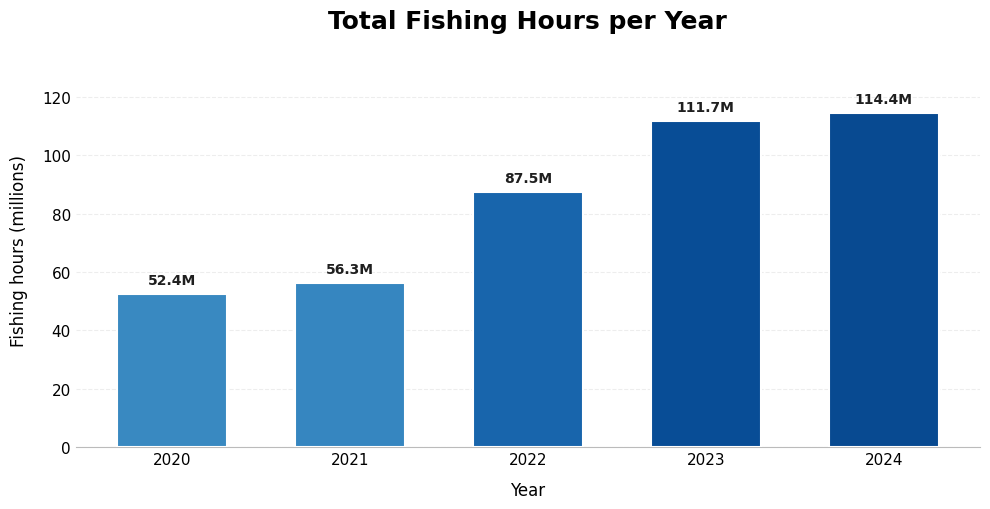

In [13]:
yearly = df.groupby("year")["fishing_hours"].sum() / 1e6  # millions of hours

norm = yearly.values / yearly.values.max()
colors = plt.cm.Blues(0.45 + 0.45 * norm)

fig, ax = plt.subplots(figsize=(10, 5.2))

bars = ax.bar(
    yearly.index,
    yearly.values,
    width=0.62,
    color=colors,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

ax.set_title(
    "Total Fishing Hours per Year",
    fontsize=18,
    fontweight="bold",
    pad=18
)
ax.set_xlabel("Year", fontsize=12, labelpad=10)
ax.set_ylabel("Fishing hours (millions)", fontsize=12, labelpad=10)

ax.set_xticks(YEARS)
ax.tick_params(axis="x", labelsize=11, length=0)
ax.tick_params(axis="y", labelsize=11, length=0)

ax.yaxis.grid(True, linestyle="--", alpha=0.22, zorder=0)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#BBBBBB")

ymax = yearly.max()
ax.set_ylim(0, ymax * 1.18)

for bar, value in zip(bars, yearly.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + ymax * 0.02,
        f"{value:.1f}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1F1F1F"
    )

plt.tight_layout()
plt.show()

/var/folders/gx/054mtq011yv3wl3578m4k9x40000gn/T/ipykernel_25860/56983632.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.92])


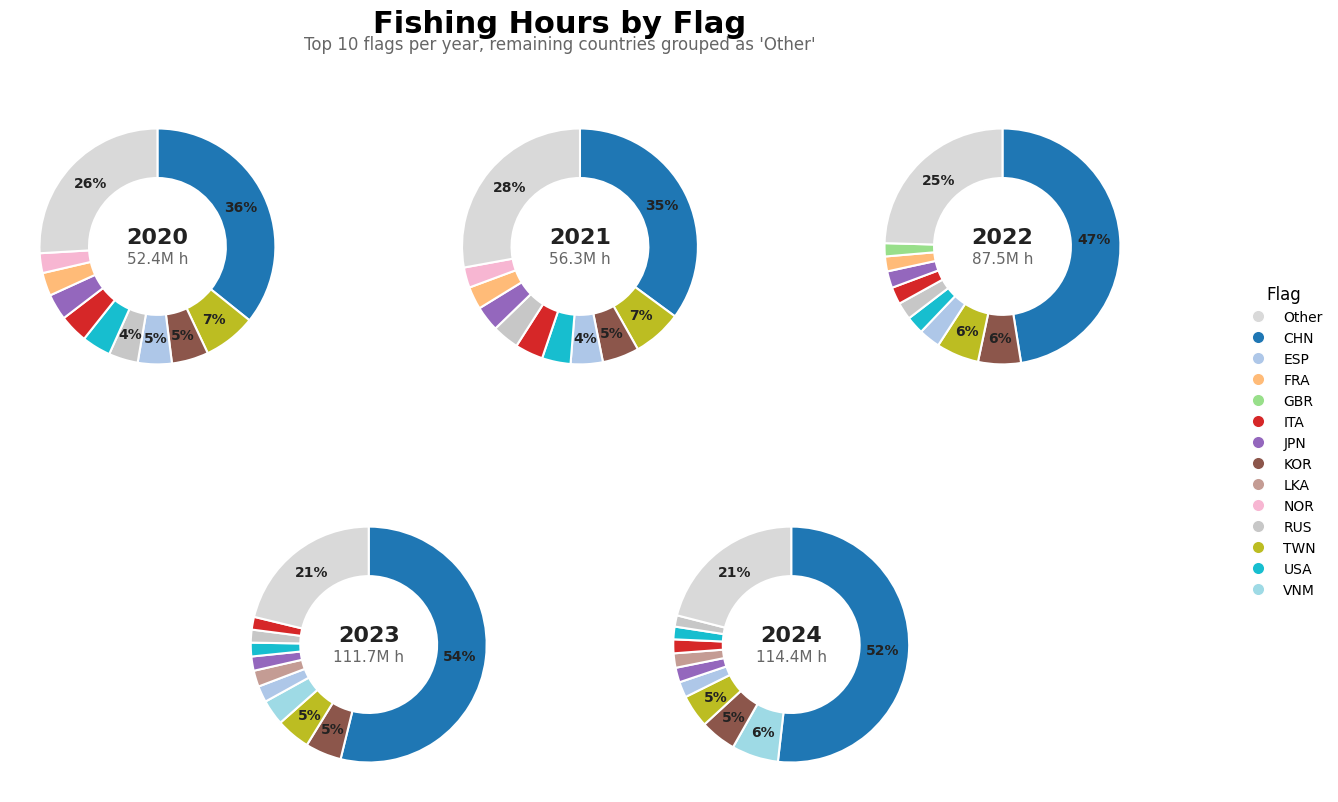

In [14]:
# ---------- Prepare yearly data ----------
def get_top10_other(year_df):
    flag_col = year_df["flag"].astype(str).str.replace(r"^UNKNOWN-", "", regex=True)
    by_flag = year_df["fishing_hours"].groupby(flag_col).sum().sort_values(ascending=False)
    top10 = by_flag.head(10)
    other = by_flag.iloc[10:].sum()
    return pd.concat([top10, pd.Series({"Other": other})])

yearly_data = {year: get_top10_other(df[df["year"] == year]) for year in YEARS}

all_flags = ["Other"] + sorted({f for pie in yearly_data.values() for f in pie.index if f != "Other"})

# Better custom palette: "Other" in light grey, the rest from tab20
base_colors = plt.cm.tab20(np.linspace(0, 1, len(all_flags) - 1))
color_map = {"Other": "#D9D9D9"}
for flag, color in zip([f for f in all_flags if f != "Other"], base_colors):
    color_map[flag] = color

# ---------- Figure layout ----------
fig = plt.figure(figsize=(16, 9), facecolor="white")
gs = fig.add_gridspec(2, 6, wspace=0.15, hspace=0.35)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

def autopct_visible(pct):
    return f"{pct:.0f}%" if pct >= 4 else ""

# ---------- Plot ----------
for ax, year in zip(axes, YEARS):
    pie_data = yearly_data[year]
    colors = [color_map[f] for f in pie_data.index]

    wedges, texts, autotexts = ax.pie(
        pie_data.values,
        labels=None,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.5),
        autopct=autopct_visible,
        pctdistance=0.78,
        textprops=dict(color="#222222", fontsize=10, fontweight="bold"),
    )

    total_m = pie_data.sum() / 1e6
    ax.text(
        0, 0.08, f"{year}",
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="#222222"
    )
    ax.text(
        0, -0.10, f"{total_m:.1f}M h",
        ha="center", va="center",
        fontsize=11, color="#666666"
    )

    ax.set_aspect("equal")

# ---------- Title ----------
fig.suptitle(
    "Fishing Hours by Flag",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5, 0.935,
    "Top 10 flags per year, remaining countries grouped as 'Other'",
    ha="center",
    fontsize=12,
    color="#666666"
)

# ---------- Common legend ----------
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=flag,
           markerfacecolor=color_map[flag], markersize=9)
    for flag in all_flags
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.92, 0.5),
    frameon=False,
    title="Flag",
    title_fontsize=12,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.9, 0.92])
plt.show()

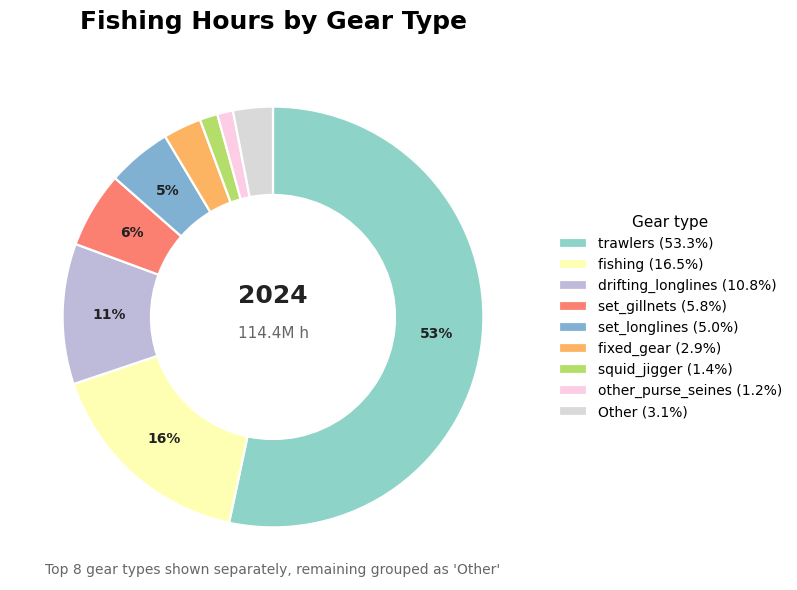

In [15]:
year = 2024
top_n = 8

year_df = df[df["year"] == year].copy()

gear_col = year_df["geartype"].astype(str).fillna("Unknown")
by_gear = year_df["fishing_hours"].groupby(gear_col).sum().sort_values(ascending=False)

top_gears = by_gear.head(top_n)
other_value = by_gear.iloc[top_n:].sum()

if other_value > 0:
    plot_data = pd.concat([top_gears, pd.Series({"Other": other_value})])
else:
    plot_data = top_gears.copy()

labels = plot_data.index
values = plot_data.values
percentages = values / values.sum() * 100

base_colors = plt.cm.Set3(range(len(labels)))
color_map = {label: color for label, color in zip(labels, base_colors)}
if "Other" in color_map:
    color_map["Other"] = "#D9D9D9"

colors = [color_map[label] for label in labels]

def autopct_func(pct):
    return f"{pct:.0f}%" if pct >= 4 else ""

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=1.6),
    autopct=autopct_func,
    pctdistance=0.78,
    textprops=dict(color="#222222", fontsize=10, fontweight="bold"),
)

total_m = values.sum() / 1e6

ax.text(
    0, 0.10, f"{year}",
    ha="center", va="center",
    fontsize=18, fontweight="bold", color="#222222"
)
ax.text(
    0, -0.08, f"{total_m:.1f}M h",
    ha="center", va="center",
    fontsize=11, color="#666666"
)

ax.set_title(
    "Fishing Hours by Gear Type",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.text(
    0, -1.22,
    f"Top {top_n} gear types shown separately, remaining grouped as 'Other'",
    ha="center",
    fontsize=10,
    color="#666666"
)

ax.legend(
    wedges,
    [f"{label} ({pct:.1f}%)" for label, pct in zip(labels, percentages)],
    title="Gear type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()